# Identifying Viraltiy Metrics - EDA

## Total number of reposts (outreach)

**Since the data (number of reposts) is discrete, I will use histogram plots to assess the distribution of reposts for each posts, rather than e.g. Kernel Density Estimation.**

**Note also that "data/processed/reposts.parquet" does not contain the post id, as this dataset just describes a graph connecting users. So we need to analyse the feed_posts and user_posts directly to find the distribution of the number of reposts.**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from pathlib import Path
import sys

BASE_PATH = Path.cwd().parent
sys.path.append(str(BASE_PATH))

In [46]:
disability_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_#Disability.parquet")
ukranianView_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_#UkrainianView.parquet")
academicSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_AcademicSky.parquet")
blackSky_posts=  pd.read_parquet(BASE_PATH/"data/processed/feed_Blacksky.parquet") 
bookSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_BookSky.parquet")
gameDev_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Game Dev.parquet")
greenSky_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_GreenSky.parquet")
news_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_News.parquet")
political_Science_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Political Science.parquet")
science_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_Science.parquet")
whats_History_posts = pd.read_parquet(BASE_PATH/"data/processed/feed_What's History.parquet")

feed_posts = [disability_posts, ukranianView_posts, academicSky_posts,
            blackSky_posts, bookSky_posts, gameDev_posts,
            greenSky_posts, news_posts, political_Science_posts,
            science_posts, whats_History_posts]

labels = ["#Disability", "#UkrainianView", "AcademicSky",
        "Blacksky", "BookSky", "Game Dev",
        "GreenSky", "News", "Political Science", "Science",
        "What's History"]

combined_feeds = pd.concat(feed_posts, ignore_index=True)

Combined feeds
Number of total posts = 168463
90.0th percentile = 8.0 (16846 posts above this percentile)
95.0th percentile = 17.0 (8423 posts above this percentile)
98.0th percentile = 41.0 (3369 posts above this percentile)
99.0th percentile = 72.0 (1685 posts above this percentile)
99.9th percentile = 275.53800000000047 (168 posts above this percentile)
99.99th percentile = 792.1532000000007 (17 posts above this percentile)
99.99900000000001th percentile = 1584.8132800066378 (2 posts above this percentile)
100th percentile = 4761.0 (0 posts above this percentile)


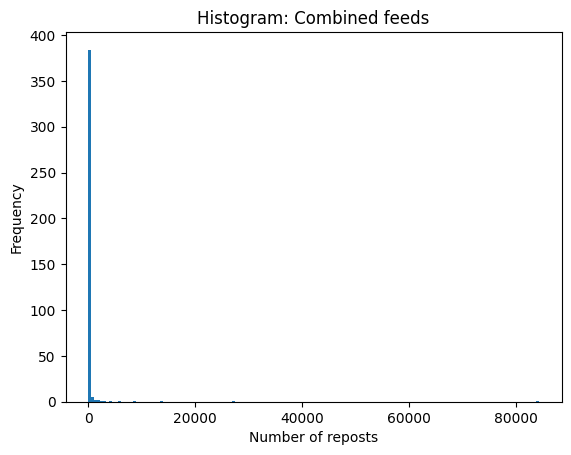

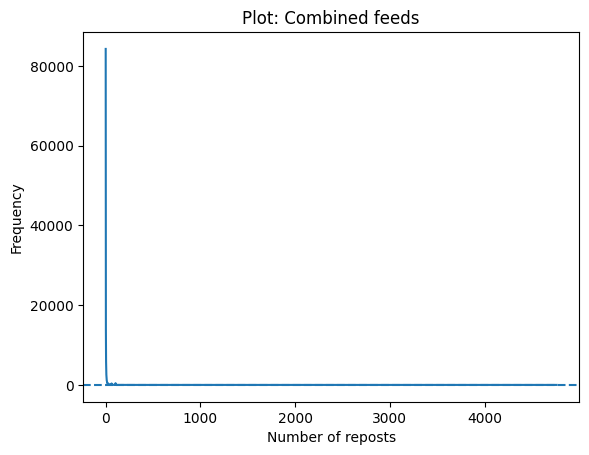

In [51]:
# Pandas Series of frequencies (value_counts), indexed by number of reposts
repost_counts = [df["repost_count"].value_counts().sort_index() for df in feed_posts]
combined_repost_counts = combined_feeds["repost_count"].value_counts().sort_index()

print("Combined feeds")
total_posts = combined_feeds.shape[0]
print(f"Number of total posts = {total_posts}")
for p in [0.9,0.95,0.98,0.99,0.999,0.9999,0.99999,1]:
    print(f"{p*100}th percentile = {combined_feeds['repost_count'].quantile(p)} ({round((1-p)*total_posts)} posts above this percentile)") # default linear interpolation

plt.hist(combined_repost_counts, bins=150)
plt.xlabel("Number of reposts")
plt.ylabel("Frequency")
plt.title("Histogram: Combined feeds")
plt.show()

combined_repost_counts.plot()
plt.xlabel("Number of reposts")
plt.ylabel("Frequency")
plt.title("Plot: Combined feeds")
plt.axhline(0.5, linestyle='--')
plt.show()

As a threshold for virality, the 95th percentile (17 reposts and above) seems way too low. A better throeshold may be the 99.99th percentile (792 reposts and above).

In [ ]:
#Visualise for each feed similarly

for i in range(len(repost_counts)):
    repost_counts[i].plot()
    plt.xlabel("Number of reposts")
    plt.ylabel("Frequency")
    plt.title("Plot: "+labels[i])
    plt.axhline(0, linestyle='--')
    plt.show()

    repost_counts[i].plot()
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Log of number of reposts")
    plt.ylabel("Log of Frequency")
    plt.title("Plot: Log of "+labels[i])
    plt.show()

There seems to be a rapid drop off in number of reposts. Is there evidence to suggest the data follows a power law or exponential distribution? 

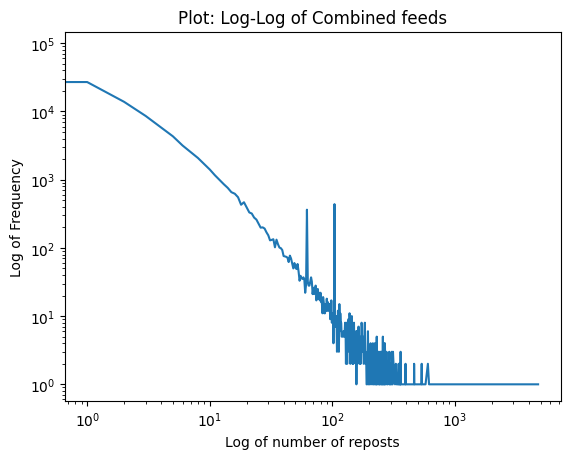

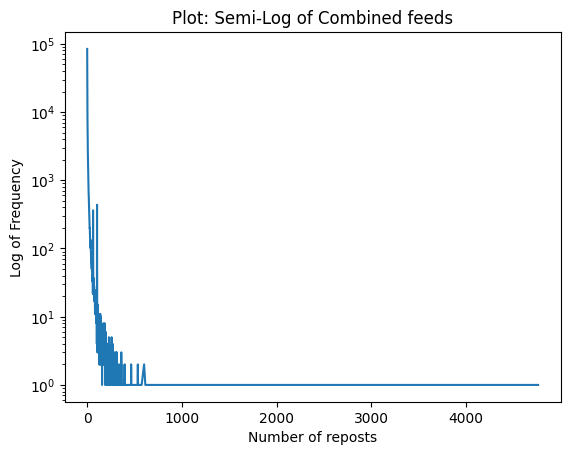

In [52]:
# Check for further evidence of power law distribution (is log-log plot linear?)
combined_repost_counts.plot()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log of number of reposts")
plt.ylabel("Log of Frequency")
plt.title("Plot: Log-Log of Combined feeds")
plt.show()

# Check for further evidence of exponential distribution (is semi-log plot linear?)
combined_repost_counts.plot()
plt.yscale("log")
plt.xlabel("Number of reposts")
plt.ylabel("Log of Frequency")
plt.title("Plot: Semi-Log of Combined feeds")
plt.show()

There is some evidence to suggest that the data (combined_feeds) follows a power law distribution. However, the data may follow a similar distribution (e.g. exponential) instead. To do this we will conduct statistical tests (Clauset et al, 2009).

In [76]:
# Clauset et al goodness of fit test
def clauset_gof_p_value(data, n_boots=100): # lower number of n_boots to make tractable
    fit = powerlaw.Fit(data, verbose=True, discrete=True)
    alpha, xmin = fit.alpha, fit.xmin

    # Empirical KS stat
    D_emp = fit.power_law.D

    # Data split
    tail = data[data >= xmin]
    body = data[data < xmin]
    n_tail = len(tail)
    n_body = len(body)
    n = len(data)

    count = 0
    for _ in range(n_boots):
        # Resample body from empirical distribution
        synth_body = np.random.choice(body, size=n_body, replace=True) if n_body > 0 else np.array([])
        # Resample tail from fitted power law
        synth_tail = powerlaw.Power_Law(xmin=xmin, parameters=[alpha], discrete=True).generate_random(n_tail)
        synth = np.concatenate([synth_body, synth_tail])

        fit_synth = powerlaw.Fit(synth, verbose=False, discrete=True)
        D_synth = fit_synth.power_law.D
        print(D_synth, D_emp)
        if D_synth >= D_emp:
            count += 1

    return D_emp, count / n_boots

data_to_fit = combined_feeds["repost_count"]
data_to_fit = data_to_fit[data_to_fit > 0]
D, p = clauset_gof_p_value(data_to_fit)
print(f"KS stat D = {D:.4f}, bootstrap p-value = {p:.3f}")

Calculating best minimal value for power law fit


Fitting xmin:   0%|          | 0/398 [00:00<?, ?it/s]

Fitting xmin: 100%|██████████| 398/398 [00:03<00:00, 121.71it/s]


0.013031866821320792 0.025620639802462652
0.010641002979833947 0.025620639802462652
0.009262692746720327 0.025620639802462652
0.010424015230485785 0.025620639802462652
0.009103048085638332 0.025620639802462652
0.011482263634702033 0.025620639802462652
0.011489518618799932 0.025620639802462652
0.010909884096667322 0.025620639802462652
0.010611274557518868 0.025620639802462652
0.011596512008953286 0.025620639802462652
0.011059603712712529 0.025620639802462652
0.00888239346789508 0.025620639802462652
0.011158435819305229 0.025620639802462652
0.013289129254877172 0.025620639802462652
0.00932326153691676 0.025620639802462652
0.010408834034753012 0.025620639802462652
0.010161184836894877 0.025620639802462652
0.011213237190984833 0.025620639802462652
0.01274726208937968 0.025620639802462652
0.00769562520801656 0.025620639802462652
0.010851329199420001 0.025620639802462652
0.010591487522309873 0.025620639802462652
0.011479654135646222 0.025620639802462652
0.009760130744671663 0.025620639802462

The test shows that there is no evidence to suggest that the data follows a powerlaw distribution. Although maybe there is a mistake with the code. The following code performs likelihood ratio tests between powerlaw, lognormal and exponential distributions.

In [80]:
fit = powerlaw.Fit(data_to_fit, verbose=True, discrete=True)
alpha, xmin = fit.alpha, fit.xmin

# Compare against alternatives
R, p = fit.distribution_compare('power_law', 'lognormal')
print(f"Power law vs log-normal: R={R:.3f}, p={p}")
# R > 0 favours power law; R < 0 favours log-normal

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Power law vs exponential: R={R:.3f}, p={p}")

R, p = fit.distribution_compare('lognormal', 'exponential')
print(f"Log-normal vs exponential: R={R:.3f}, p={p}")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 398/398 [00:02<00:00, 143.65it/s]


Power law vs log-normal: R=-131.006, p=2.652957309261169e-23
Power law vs exponential: R=3371.801, p=6.249431679857909e-53
Log-normal vs exponential: R=3502.807, p=5.714426174461687e-62


This seems to suggest that the data is more likely from a lognormal distribution (perhaps truncated). However, this may not be the case

## How fast the post is spread throughout the network

An alternative definition of virality lies in how quickly a post spreads throughout the network, i.e. how fast the number of reposts increases. This is in line with various academic defintions [[1]](#1).

*References*<br>
<a id="1">[1]</a> 
Denisova, A. (2020) “How to Define ‘Viral’ for Media Studies?”, Westminster Papers in Communication and Culture. 15(1). doi: https://doi.org/10.16997/wpcc.375

In [ ]:
reposts_graph = pd.read_parquet(BASE_PATH/"data/processed/reposts.parquet")

In [10]:
print(reposts_graph.columns)
print(reposts_graph.shape)
print(reposts_graph.head)

Index(['user_id', 'reposted_author', 'date'], dtype='str')
(63438069, 3)
<bound method NDFrame.head of           user_id  reposted_author      date
0          836672           833271  20230919
1          836672            61971  20231002
2          836672            47191  20230923
3          836672            17234  20230930
4          836672            20490  20230726
...           ...              ...       ...
63438064  3982320           439663  20230725
63438065   854974           587345  20231027
63438066  3254946              937  20240207
63438067  3254946           925392  20240207
63438068  3254946           337953  20240206

[63438069 rows x 3 columns]>


Note that these datasets do not contain the post_id (likely due to anonymisation), so it is difficult to conduct a temporal analysis on the number of reposts of a specific post. The timestamp is also just a date.

So, as a workaround, we can analyse how the number of reposts a user recieves on a particular day compares to the number of posts they make that day. Or conisder the quantity: # reposts that day / number of posts that day.

A potential conditions for a post to be viral (both simultaneously):
- hits threshold some of # reposts
- It's date (date created) and user_id correspond to date which user has high # reposts per # posts that day.

In [31]:
# Create dataframe for number of reposts of a user each day
user_reposts_per_day = reposts_graph.groupby(["user_id","date"]).size().reset_index(name='num_reposts')
print(user_reposts_per_day.head())

   user_id      date  num_reposts
0        0  20231018            1
1        0  20231117            1
2        0  20231119           13
3        0  20231120            8
4        0  20231121           12


In [36]:
user_reposts_per_day.to_parquet(BASE_PATH/'data/processed/num_reposts_user_date.parquet')

print(user_reposts_per_day)
total = user_reposts_per_day.shape[0]
print(f"Total = {total}")
for p in [0.9,0.95,0.98,0.99,0.999,0.9999,0.99999,1]:
    print(f"{p*100}th percentile = {user_reposts_per_day['num_reposts'].quantile(p)} ({round((1-p)*total)} (user,day)s above this percentile)") # default linear interpolation

          user_id       date  num_reposts
0               0 2023-10-18            1
1               0 2023-11-17            1
2               0 2023-11-19           13
3               0 2023-11-20            8
4               0 2023-11-21           12
...           ...        ...          ...
18577037  4099408 2024-02-28            2
18577038  4099408 2024-03-13            1
18577039  4099566 2024-02-13            1
18577040  4099601 2024-02-26            1
18577041  4099673 2024-02-13            1

[18577042 rows x 3 columns]
Total = 18577042
90.0th percentile = 6.0 (1857704 (user,day)s above this percentile)
95.0th percentile = 11.0 (928852 (user,day)s above this percentile)
98.0th percentile = 22.0 (371541 (user,day)s above this percentile)
99.0th percentile = 34.0 (185770 (user,day)s above this percentile)
99.9th percentile = 108.0 (18577 (user,day)s above this percentile)
99.99th percentile = 272.0 (1858 (user,day)s above this percentile)
99.99900000000001th percentile = 597.45918

Similar distribution to that of the # reposts. Like scale has been shifted, which makes sense as this only looks at posts which have reposted.

Now analyse distribution of  # reposts per # posts created each day for each user (from sample of 1,000,000 (user,day)s ).

   user_id       date  post_count
0   702349 2023-11-16          28
1    27933 2023-11-14           4
2  1909178 2024-02-08           1
3   180767 2023-09-30           8
4  2089423 2024-02-07           2
   user_id       date  num_reposts
0        0 2023-10-18            1
1        0 2023-11-17            1
2        0 2023-11-19           13
3        0 2023-11-20            8
4        0 2023-11-21           12
   user_id       date  num_reposts  post_count
0        5 2023-05-18            1           1
1        5 2023-08-18           36          51
2        5 2023-08-31            9          18
3        5 2023-10-10           28          35
4        5 2023-11-22           21          24
Total = 416155
90.0th percentile = 1.0 (41615 (user,day)s above this percentile)
95.0th percentile = 1.0 (20808 (user,day)s above this percentile)
98.0th percentile = 1.0 (8323 (user,day)s above this percentile)
99.0th percentile = 1.0 (4162 (user,day)s above this percentile)
99.9th percentile = 1.0 (41

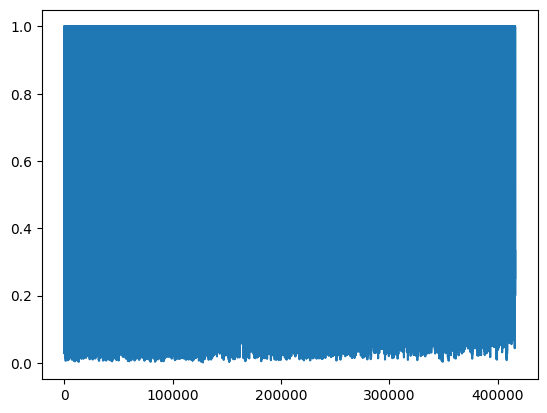

In [33]:
post_count_user_date_sample = pd.read_parquet(BASE_PATH/'data/processed/post_count_user_date_SAMPLE.parquet')
print(post_count_user_date_sample.head())

user_reposts_per_day["date"] =  pd.to_datetime(user_reposts_per_day['date'].astype(str), format='%Y%m%d')
print(user_reposts_per_day.head())

user_day = pd.merge(user_reposts_per_day, post_count_user_date_sample, on=["user_id","date"], how='inner')

print(user_day.head())
num_reposts_per_posts_created = user_day["num_reposts"] / user_day["post_count"]

num_reposts_per_posts_created.plot()

total = num_reposts_per_posts_created.shape[0]
print(f"Total = {total}")
for p in [0.9,0.95,0.98,0.99,0.999,0.9999,0.99999,1]:
    print(f"{p*100}th percentile = {num_reposts_per_posts_created.quantile(p)} ({round((1-p)*total)} (user,day)s above this percentile)") # default linear interpolation

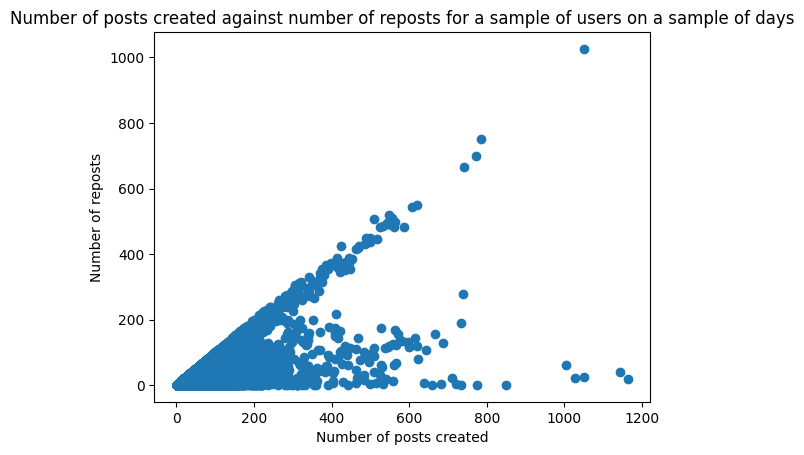

In [34]:
# Plot Number of posts created against number of reposts for (user, date)
plt.scatter(user_day["post_count"], user_day["num_reposts"])
plt.xlabel("Number of posts created")
plt.ylabel("Number of reposts")
plt.title("Number of posts created against number of reposts for a sample of users on a sample of days")
plt.show()

There is clearly correlation.
Potential reasons:
- The more posts created -> more reposts
- The more reposts -> more posts created (high engagement may lead to author responding to comments, responses are posts)

In fact the # of reposts seems to act as a cap on the # of posts ( # posts rarely exceeds number of # reposts and never by much).

Note also that for posts with a high number of reposts (viral posts) the correlation is almost perfectly linear.

We have data on replies as well, so we can alnalyse how many of these posts created are replies.

In [41]:
# Create dataframe for number of reposts of a user each day
replies_graph = pd.read_parquet(BASE_PATH/"data/processed/replies.parquet")
user_replies_per_day = replies_graph.groupby(["user_id","date"]).size().reset_index(name='num_replies')
print(user_replies_per_day.head())

   user_id      date  num_replies
0        0  20231119            1
1        0  20231120            1
2        0  20231123            4
3        0  20231124            1
4        0  20231125            1


In [42]:
user_replies_per_day.to_parquet(BASE_PATH/'data/processed/num_replies_user_date.parquet')

In [43]:
print(user_replies_per_day)
total = user_replies_per_day.shape[0]
print(f"Total = {total}")
for p in [0.9,0.95,0.98,0.99,0.999,0.9999,0.99999,1]:
    print(f"{p*100}th percentile = {user_replies_per_day['num_replies'].quantile(p)} ({round((1-p)*total)} (user,day)s above this percentile)") # default linear interpolation

          user_id      date  num_replies
0               0  20231119            1
1               0  20231120            1
2               0  20231123            4
3               0  20231124            1
4               0  20231125            1
...           ...       ...          ...
19182657  4099497  20240310            2
19182658  4099571  20240214            1
19182659  4099601  20240209            1
19182660  4099601  20240217            1
19182661  4099673  20240211            2

[19182662 rows x 3 columns]
Total = 19182662
90.0th percentile = 10.0 (1918266 (user,day)s above this percentile)
95.0th percentile = 17.0 (959133 (user,day)s above this percentile)
98.0th percentile = 30.0 (383653 (user,day)s above this percentile)
99.0th percentile = 45.0 (191827 (user,day)s above this percentile)
99.9th percentile = 121.0 (19183 (user,day)s above this percentile)
99.99th percentile = 254.0 (1918 (user,day)s above this percentile)
99.99900000000001th percentile = 549.1733900010586 (1

   user_id       date  num_reposts  num_replies
0        0 2023-11-19           13            1
1        0 2023-11-20            8            1
2        0 2023-11-23            4            4
3        0 2023-11-24            5            1
4        0 2023-11-25           10            1
Total = 7765948
90.0th percentile = 4.0 (776595 (user,day)s above this percentile)
95.0th percentile = 6.0 (388297 (user,day)s above this percentile)
98.0th percentile = 10.0 (155319 (user,day)s above this percentile)
99.0th percentile = 14.0 (77659 (user,day)s above this percentile)
99.9th percentile = 39.0 (7766 (user,day)s above this percentile)
99.99th percentile = 92.0 (777 (user,day)s above this percentile)
99.99900000000001th percentile = 205.34053000062704 (78 (user,day)s above this percentile)
100th percentile = 645.0 (0 (user,day)s above this percentile)


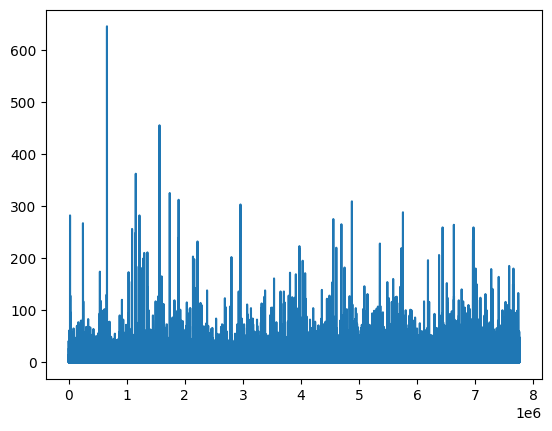

In [45]:
user_replies_per_day["date"] =  pd.to_datetime(user_replies_per_day['date'].astype(str), format='%Y%m%d')

reposts_against_replies_user_date = pd.merge(user_reposts_per_day, user_replies_per_day, on=["user_id","date"], how='inner')

print(reposts_against_replies_user_date.head())
num_reposts_per_replies = reposts_against_replies_user_date["num_reposts"] / reposts_against_replies_user_date["num_replies"]

num_reposts_per_replies.plot()

total = num_reposts_per_replies.shape[0]
print(f"Total = {total}")
for p in [0.9,0.95,0.98,0.99,0.999,0.9999,0.99999,1]:
    print(f"{p*100}th percentile = {num_reposts_per_replies.quantile(p)} ({round((1-p)*total)} (user,day)s above this percentile)") # default linear interpolation

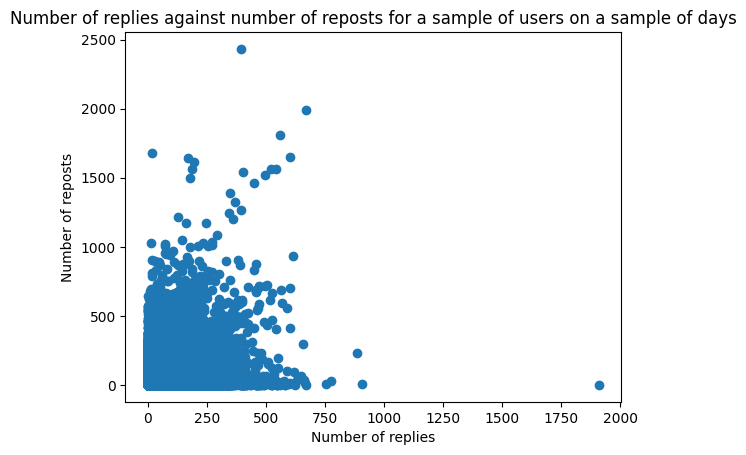

In [47]:
# Plot Number of posts created against number of reposts for (user, date)
plt.scatter(reposts_against_replies_user_date["num_replies"], reposts_against_replies_user_date["num_reposts"])
plt.xlabel("Number of replies")
plt.ylabel("Number of reposts")
plt.title("Number of replies against number of reposts for a sample of users on a sample of days")
plt.show()

Much less obvious correlation. This may suggest that # posts -> # reposts is a more likely explanation, although further analysis is required.